In [4]:
pip install ultralytics opencv-python

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


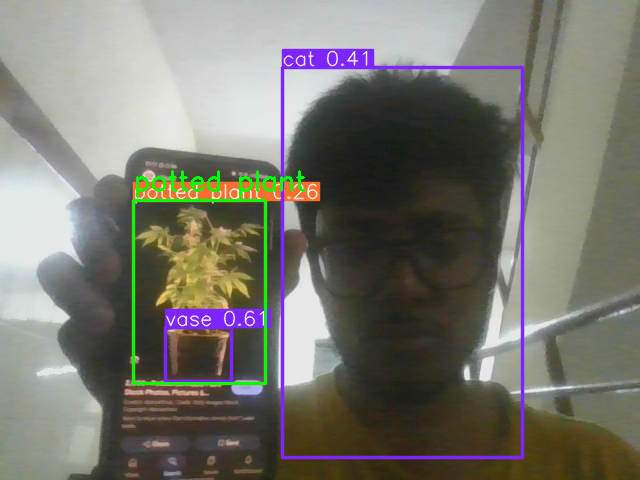


0: 480x640 1 person, 2 cats, 121.3ms
Speed: 2.8ms preprocess, 121.3ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 2 persons, 1 cat, 106.0ms
Speed: 2.4ms preprocess, 106.0ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 181.2ms
Speed: 2.0ms preprocess, 181.2ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 377.9ms
Speed: 2.4ms preprocess, 377.9ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 cat, 179.1ms
Speed: 2.3ms preprocess, 179.1ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 cat, 405.6ms
Speed: 2.0ms preprocess, 405.6ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 cat, 167.0ms
Speed: 3.3ms preprocess, 167.0ms inference, 2.1ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 cat, 126.8ms
Speed: 3.7ms preprocess, 126.8ms inference, 1.3ms postprocess per imag

KeyboardInterrupt: 

In [1]:
import cv2
from ultralytics import YOLO
from IPython.display import display, clear_output
from PIL import Image
import numpy as np

# Load the YOLOv8 model (ensure the correct path to the model file)
model = YOLO("yolov8n.pt")  # Adjust if necessary

# Open webcam
cap = cv2.VideoCapture(0)

# Define the target class for detection
target_class = 'potted plant'

# List of possible class names that YOLO can detect (this should match YOLOv8's class names)
valid_classes = ['potted plant']

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Run YOLOv8 inference on the frame
    results = model(frame)

    # Annotate the frame with bounding boxes for all detected objects
    annotated_frame = results[0].plot()

    # Flag to check if potted plant is detected in the frame
    plant_detected = False

    # Loop through all detected objects in the results
    for result in results:
        boxes = result.boxes
        for box in boxes:
            cls_id = int(box.cls[0])  # Get the class ID of the detected object
            cls_name = model.names[cls_id]  # Get the name of the detected class
            
            # Check if the detected object matches the target class
            if cls_name == target_class:
                # Extract coordinates of the bounding box
                x1, y1, x2, y2 = box.xyxy[0]
                # Draw the bounding box and label for the detected potted plant
                cv2.rectangle(annotated_frame, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
                cv2.putText(annotated_frame, f'{cls_name}', (int(x1), int(y1) - 10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
                plant_detected = True
                print(f"Detected {cls_name} at coordinates: ({x1}, {y1}), ({x2}, {y2})")

    # If a potted plant was detected, show the frame
    if plant_detected:
        # Convert BGR frame to RGB for displaying in notebook
        rgb_frame = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)
        img = Image.fromarray(rgb_frame)

        # Display the frame
        clear_output(wait=True)
        display(img)

    # Optional: Add a stop condition or break after a certain time
    # You can set a time limit or a condition for quitting the loop here
    # Example: quit after 25 seconds
    # If you want to stop after a fixed time (e.g., 25 seconds), you can add:
    # import time
    # if time.time() - start_time > 25:
    #    break

# Cleanup
cap.release()
cv2.destroyAllWindows()
